In [ ]:
#installing spark

In [1]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q https://archive.apache.org/dist/spark/spark-3.4.1/spark-3.4.1-bin-hadoop3.tgz
!tar xf spark-3.4.1-bin-hadoop3.tgz
!pip install -q findspark

In [ ]:
#starting a spark session

In [2]:
import os
import findspark

os.environ["SPARK_HOME"] = "/content/spark-3.4.1-bin-hadoop3"
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ProteinFeatures") \
    .getOrCreate()

print("Spark Running")

Spark Running


In [ ]:
#upload and extract dataset

In [3]:
import gzip

file_path = "/content/UP000000625.fasta.gz"

with gzip.open(file_path, "rt") as f:
    lines = f.readlines()

print(lines[:5])  # just to check it loaded

['>tr|A0A0H3JIP3|A0A0H3JIP3_ECO57 DUF1378 family protein OS=Escherichia coli O157:H7 OX=83334 GN=ECs_1210 PE=4 SV=1 UPId=UP000000558 PPId=UP000000625\n', 'MTFLNQLMLYFCTVVCVLYLLSGGYRAMRDFWRRQIDKRAAEKISASQSAGSKPEEPLI\n', '>tr|Q7DB73|Q7DB73_ECO57 T3SS structure protein SepQ OS=Escherichia coli O157:H7 OX=83334 GN=sepQ PE=4 SV=1 UPId=UP000000558 PPId=UP000000625\n', 'MKPLSSQLNMKINDFYLPLLPVIGTGRLYITSKGHACHAYFREVSGHGIRFTLTYSGYEG\n', 'RFWISEEQFIQWCQELFPYSESRLIPEDTIKLMILWVMQTALPEGDVSVDDVQFTMLNKD\n']


In [ ]:
#parse FASTA sequences

In [4]:
proteins = []
header = ""
sequence = ""

for line in lines:
    line = line.strip()

    if line.startswith(">"):
        if sequence:
            proteins.append((header, sequence))
        header = line
        sequence = ""
    else:
        sequence += line

proteins.append((header, sequence))

In [ ]:
#create spark dataframe

In [5]:
df = spark.createDataFrame(proteins, ["header", "sequence"])

df.show(5)

+--------------------+--------------------+
|              header|            sequence|
+--------------------+--------------------+
|>tr|A0A0H3JIP3|A0...|MTFLNQLMLYFCTVVCV...|
|>tr|Q7DB73|Q7DB73...|MKPLSSQLNMKINDFYL...|
|>tr|Q7DB52|Q7DB52...|MITITELEDEIIKNKEA...|
|>tr|Q7DB71|Q7DB71...|MISEHDSVLEKYPRIQK...|
|>tr|Q7AEZ5|Q7AEZ5...|MTAELRNLPHIASMAFN...|
+--------------------+--------------------+
only showing top 5 rows



In [ ]:
#Feature Extraction

In [6]:
from pyspark.sql.functions import length

df = df.withColumn("length", length(df.sequence))

In [ ]:
#Count Amino Acid A

In [7]:
from pyspark.sql.functions import udf
from pyspark.sql.types import IntegerType

def count_A(seq):
    return seq.count("A")

count_A_udf = udf(count_A, IntegerType())

df = df.withColumn("A_count", count_A_udf(df.sequence))

In [ ]:
#Distributed Operations

In [8]:
df.cache()

DataFrame[header: string, sequence: string, length: int, A_count: int]

In [9]:
df.repartition(4)

DataFrame[header: string, sequence: string, length: int, A_count: int]

In [ ]:
#Average Protein Length

In [10]:
df.selectExpr("avg(length)").show()

+-----------------+
|      avg(length)|
+-----------------+
|176.9738063164197|
+-----------------+



In [ ]:
#Longest Proteins

In [11]:
df.orderBy(df.length.desc()).show(10)

+--------------------+--------------------+------+-------+
|              header|            sequence|length|A_count|
+--------------------+--------------------+------+-------+
|>tr|A0A0H3JG23|A0...|MPASAVGALGEASYTVT...|  5291|    701|
|>tr|A0AAE9RED3|A0...|MTNFIVVEKDSLNKVSI...|  4897|    425|
|>tr|A0A9Q5THN5|A0...|MTTIKNRRLRPRAHRFA...|  4264|    483|
|>tr|A0A370V448|A0...|MSLIIDVISRKTSVKQT...|  3604|    481|
|>tr|A0A370V436|A0...|MTVPASAVGSLGEATYT...|  3600|    462|
|>tr|A0A1D7Q6I3|A0...|MAGKAHGNGDRRGDNTI...|  3515|    429|
|>tr|A0AAJ2Y2Y7|A0...|MTNNFKFQPTQMAEAVQ...|  3323|    131|
|>tr|A0A828N5S3|A0...|MAGKAHGNGDRRGDNTI...|  3224|    370|
|>tr|B7UI23|B7UI23...|MRLPEKVLFPPVTSGLS...|  3223|    156|
|>tr|A0A0H2V540|A0...|MHQPPVRFTYRLLSYLV...|  3216|    342|
+--------------------+--------------------+------+-------+
only showing top 10 rows



In [ ]:
#Summary Statistics

In [12]:
df.describe(["length"]).show()

+-------+-----------------+
|summary|           length|
+-------+-----------------+
|  count|           100215|
|   mean|176.9738063164197|
| stddev|172.4909307849009|
|    min|               11|
|    max|             5291|
+-------+-----------------+



In [ ]:
#Convert to Pandas for Plotting

In [13]:
pandas_df = df.select("length").toPandas()

In [ ]:
#Create Plots

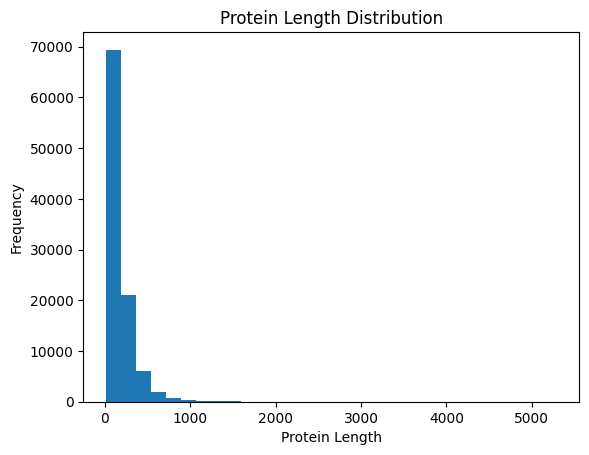

In [14]:
import matplotlib.pyplot as plt

plt.hist(pandas_df["length"], bins=30)
plt.xlabel("Protein Length")
plt.ylabel("Frequency")
plt.title("Protein Length Distribution")
plt.show()

In [17]:
from pyspark.sql.functions import when

df = df.withColumn(
    "family",
    when(df.header.contains("ribosomal"), "Ribosomal")
    .when(df.header.contains("transport"), "Transport")
    .otherwise("Other")
)

In [ ]:
#family lavel distrubution

In [18]:
family_counts = df.groupBy("family").count()
family_counts.show()

+---------+-----+
|   family|count|
+---------+-----+
|    Other|93949|
|Ribosomal|  382|
|Transport| 5884|
+---------+-----+



In [19]:
pdf = family_counts.toPandas()

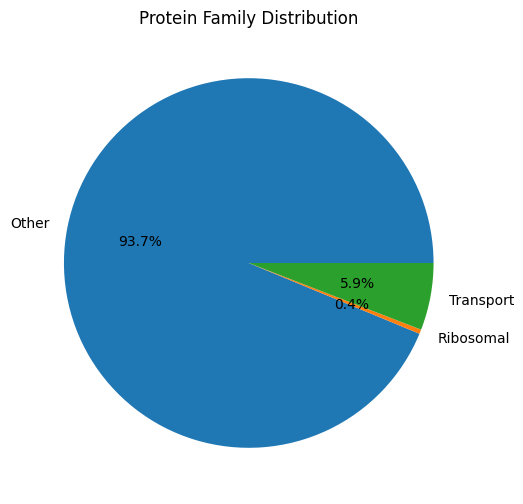

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.pie(pdf["count"], labels=pdf["family"], autopct="%1.1f%%")
plt.title("Protein Family Distribution")
plt.show()

In [ ]:
#aminoacid composition

In [32]:
from pyspark.sql.functions import udf
from pyspark.sql.types import MapType, StringType, IntegerType

amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

def aa_composition(seq):
    return {aa: seq.count(aa) for aa in amino_acids}

aa_udf = udf(aa_composition, MapType(StringType(), IntegerType()))

df = df.withColumn("aa_comp", aa_udf(df.sequence))

In [33]:
aa_totals = {aa: 0 for aa in amino_acids}

rows = df.select("aa_comp").collect()

for row in rows:
    comp = row["aa_comp"]
    for aa in amino_acids:
        aa_totals[aa] += comp[aa]

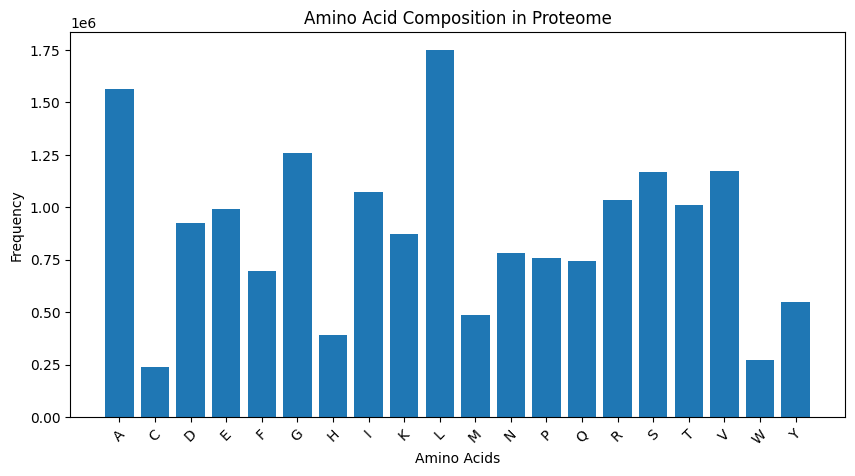

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(aa_totals.keys(), aa_totals.values())
plt.title("Amino Acid Composition in Proteome")
plt.xlabel("Amino Acids")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [24]:
#count motifs
def motif_count(seq):
    return seq.count("GGG")

motif_udf = udf(motif_count, IntegerType())

df = df.withColumn("GGG_motif_count", motif_udf(df.sequence))

In [25]:
def count_motifs(seq):
    motifs = {
        "AAA": seq.count("AAA"),
        "GGG": seq.count("GGG"),
        "KKK": seq.count("KKK")
    }
    return motifs

In [26]:
from pyspark.sql.functions import udf
from pyspark.sql.types import MapType, StringType, IntegerType

def count_motifs(seq):
    return {
        "AAA": seq.count("AAA"),
        "GGG": seq.count("GGG"),
        "KKK": seq.count("KKK")
    }

motif_udf = udf(count_motifs, MapType(StringType(), IntegerType()))

df = df.withColumn("motifs", motif_udf(df.sequence))

In [27]:
from pyspark.sql.functions import sum as _sum

aaa_total = df.rdd.map(lambda x: x["motifs"]["AAA"]).sum()
ggg_total = df.rdd.map(lambda x: x["motifs"]["GGG"]).sum()
kkk_total = df.rdd.map(lambda x: x["motifs"]["KKK"]).sum()

In [28]:
motif_data = {
    "AAA": aaa_total,
    "GGG": ggg_total,
    "KKK": kkk_total
}

In [29]:
import pandas as pd

motif_df = pd.DataFrame(list(motif_data.items()), columns=["Motif", "Count"])
motif_df

,Motif,Count
0,AAA,14556
1,GGG,7292
2,KKK,2521


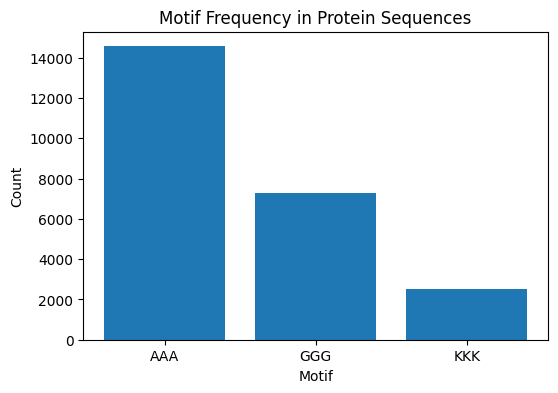

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(motif_df["Motif"], motif_df["Count"])
plt.title("Motif Frequency in Protein Sequences")
plt.xlabel("Motif")
plt.ylabel("Count")
plt.show()

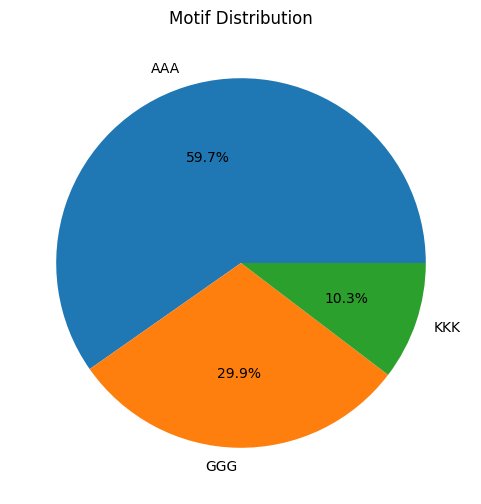

In [31]:
plt.figure(figsize=(6,6))
plt.pie(motif_df["Count"], labels=motif_df["Motif"], autopct="%1.1f%%")
plt.title("Motif Distribution")
plt.show()